# Input

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import numpy as np
import seaborn as sns

import pandas as pd
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from hiara import PLOTS_DIR, CLOCK_TRAINING_COHORTS, CELL_TYPES, AGING_COHORTS, OUTPUT_DIR, \
        palette_datasets_pretty, surrogate_names, palette_cell_types, colors_blind, clock_version

from hiara import retrieve_net_consensus
from hiara.src.clock.helper import get_all_predictions
from hiara.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' 
tune_model = True
create_smoothed_data = True
only_targets = True
temp_dir = f'{OUTPUT_DIR}/temp/'
plt.rcParams["font.family"] = "Arial"
cell_types = ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
train_datasets = CLOCK_TRAINING_COHORTS
n_cell_types = len(cell_types)
version = clock_version

print(train_datasets)

['onek1k', 'abf300']


# Train the model

In [2]:
if True:
    # Use GRNimmuneClock training module instead of subprocess
    from pathlib import Path
    from grnimmuneclock import train_aging_clock
    
    for cell_type in cell_types:
        print(f"\n{'='*60}")
        print(f"Training {cell_type} aging clock")
        print(f"{'='*60}")
        
        model, predictions, adata_train = train_aging_clock(
            cell_type=cell_type,
            datasets=train_datasets,
            data_type=data_type,
            reg_type=reg_type,
            tune_model=tune_model,
            output_dir=Path(OUTPUT_DIR) / 'clock',
            version=version,
            verbose=True
        )
        model_dir = Path(temp_dir) / cell_type
        model_dir.mkdir(parents=True, exist_ok=True)
        adata_train.write(f"{model_dir}/adata_train.h5ad")
        
        print(f"\n✓ {cell_type} model trained and saved")
        print(f"  Training R²: {adata_train.obs[['age', 'predicted_age']].corr().iloc[0,1]**2:.3f}")


Training CD4T aging clock
Training aging clock for CD4T
Datasets: ['onek1k', 'abf300']
Retrieving consensus GRN for CD4T with min degree 2
Retrieving consensus GRN for CD4T with min degree 2


[I 2026-01-13 12:16:05,805] A new study created in memory with name: no-name-cd48cebf-50c8-43ff-8ff3-910baac81cb0


Merged data shape: (1289, 3771)
Datasets: {'onek1k': 976, 'abf300': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-13 12:16:05,861] Trial 0 finished with value: 0.48813081798223323 and parameters: {'alpha': 5.160565351056344}. Best is trial 0 with value: 0.48813081798223323.
[I 2026-01-13 12:16:06,007] Trial 1 finished with value: 0.4876061175652777 and parameters: {'alpha': 6.253889152126237}. Best is trial 0 with value: 0.48813081798223323.
[I 2026-01-13 12:16:06,064] Trial 2 finished with value: 0.49060616702309046 and parameters: {'alpha': 0.05001385097344755}. Best is trial 2 with value: 0.49060616702309046.
[I 2026-01-13 12:16:06,117] Trial 3 finished with value: 0.49033721183349366 and parameters: {'alpha': 0.6015458530837519}. Best is trial 2 with value: 0.49060616702309046.
[I 2026-01-13 12:16:06,169] Trial 4 finished with value: 0.4898901386389629 and parameters: {'alpha': 1.5203431102559413}. Best is trial 2 with value: 0.49060616702309046.
[I 2026-01-13 12:16:06,211] Trial 5 finished with value: 0.490617251423736 and parameters: {'alpha': 0.027303084326001058}. Best is trial 

...

[I 2026-01-13 12:17:54,323] Trial 0 finished with value: -0.5171837525079928 and parameters: {'alpha': 2.784719429844447}. Best is trial 0 with value: -0.5171837525079928.
[I 2026-01-13 12:17:54,380] Trial 1 finished with value: -0.533720937214154 and parameters: {'alpha': 52.53146012012509}. Best is trial 0 with value: -0.5171837525079928.
[I 2026-01-13 12:17:54,443] Trial 2 finished with value: -0.5525917807552732 and parameters: {'alpha': 119.60083674842697}. Best is trial 0 with value: -0.5171837525079928.
[I 2026-01-13 12:17:54,502] Trial 3 finished with value: -0.5237674779523767 and parameters: {'alpha': 21.738402735625467}. Best is trial 0 with value: -0.5171837525079928.
[I 2026-01-13 12:17:54,564] Trial 4 finished with value: -0.5164259904081223 and parameters: {'alpha': 0.669070357673263}. Best is trial 4 with value: -0.5164259904081223.
[I 2026-01-13 12:17:54,617] Trial 5 finished with value: -0.516195443763408 and parameters: {'alpha': 0.02798429927409405}. Best is trial 5

[I 2026-01-13 12:18:31,513] A new study created in memory with name: no-name-eb6b8b48-b89b-43c1-933a-e420aaccfd5f


Merged data shape: (1287, 3941)
Datasets: {'onek1k': 975, 'abf300': 312}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-13 12:18:31,556] Trial 0 finished with value: -1.6786137566475285 and parameters: {'alpha': 46.72119141683978}. Best is trial 0 with value: -1.6786137566475285.
[I 2026-01-13 12:18:31,601] Trial 1 finished with value: -1.7978038465523825 and parameters: {'alpha': 12.668356933566107}. Best is trial 0 with value: -1.6786137566475285.
[I 2026-01-13 12:18:31,696] Trial 2 finished with value: -1.8195862822145297 and parameters: {'alpha': 6.89030866911644}. Best is trial 0 with value: -1.6786137566475285.
[I 2026-01-13 12:18:31,784] Trial 3 finished with value: -1.829665050601605 and parameters: {'alpha': 4.260269178356781}. Best is trial 0 with value: -1.6786137566475285.
[I 2026-01-13 12:18:31,831] Trial 4 finished with value: -1.845077389058992 and parameters: {'alpha': 0.2905320292896725}. Best is trial 0 with value: -1.6786137566475285.
[I 2026-01-13 12:18:31,878] Trial 5 finished with value: -1.8461751987612653 and parameters: {'alpha': 0.010145735337430434}. Best is trial 0

# Cross-validation performance

Retrieving consensus GRN for CD4T with min degree 2
Retrieving consensus GRN for CD4T with min degree 2
Retrieving consensus GRN for CD8T with min degree 2
Retrieving consensus GRN for CD8T with min degree 2
Retrieving consensus GRN for MONO with min degree 2
Retrieving consensus GRN for MONO with min degree 2
Retrieving consensus GRN for B with min degree 2
Retrieving consensus GRN for B with min degree 2
Retrieving consensus GRN for NK with min degree 2
Retrieving consensus GRN for NK with min degree 2
r2 scores fig:  /vol/projects/jnourisa//output//plots//clock_validation_r2.png
spearman scores fig:  /vol/projects/jnourisa//output//plots//clock_validation_spearman.png
Scatter plot for CD4T:  /vol/projects/jnourisa//output//plots//clock_scatter_CD4T_all_datasets.png
Scatter plot for CD8T:  /vol/projects/jnourisa//output//plots//clock_scatter_CD8T_all_datasets.png
Scatter plot for MONO:  /vol/projects/jnourisa//output//plots//clock_scatter_MONO_all_datasets.png
Scatter plot for B:  /v

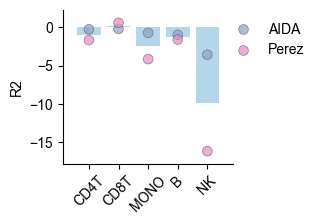

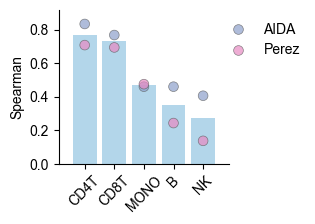

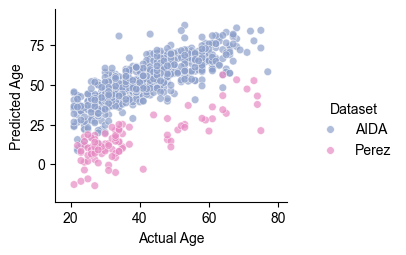

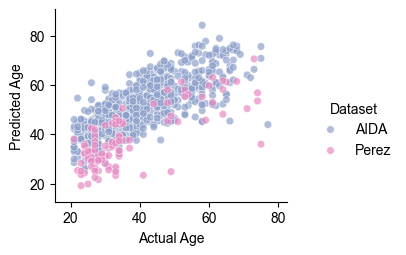

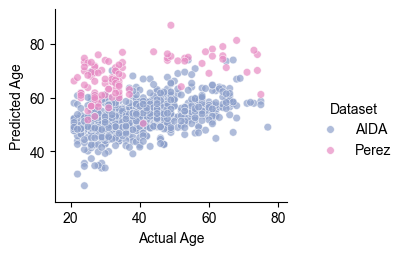

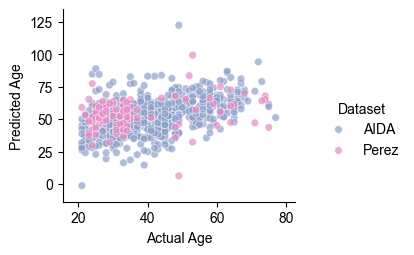

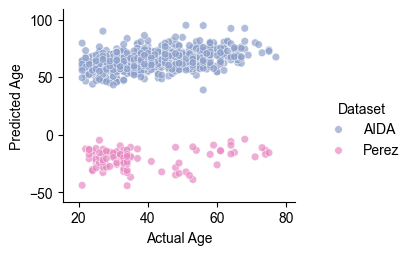

In [3]:
from hiara.src.config import CLOCK_TEST_COHORTS
obs = get_all_predictions(cell_types, CLOCK_TEST_COHORTS, condition='healthy')

import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

fold_scores = {}
all_preds = []
for (cell_type_name, dataset_name), df in obs.groupby(['cell_type', 'dataset']):
    y_true = df['age'].values
    y_pred = df['predicted_age'].values
    spearman_corr = spearmanr(y_true, y_pred).correlation
    r2 = r2_score(y_true, y_pred)
    fold_scores[(cell_type_name, dataset_name)] = {
        'spearman': round(spearman_corr, 3),
        'r2': round(r2, 3)
    }
    pred_df = df.copy()
    all_preds.append(pred_df)

scores_df = pd.DataFrame.from_dict(fold_scores, orient='index')
scores_df.index = pd.MultiIndex.from_tuples(scores_df.index, names=['cell_type', 'dataset'])
predictions_df = pd.concat(all_preds)
scores_df = scores_df.reset_index()  # make cell_type and dataset columns
scores_df['dataset'] = scores_df['dataset'].map(lambda name: surrogate_names.get(name, name))

def plot_scores(cv_scores, metric, figsize=[2.5, 2]):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    sns.stripplot(
        data=cv_scores, x='cell_type', y=metric,
        hue='dataset', dodge=False, jitter=False, s=7,
        alpha=0.7, linewidth=0.5, edgecolor='gray', palette=palette_datasets_pretty,
        ax=ax
    )
    sns.barplot(
        data=cv_scores, x='cell_type', y=metric,
        estimator='mean', errorbar=None,
        color=colors_blind[1], alpha=0.5, ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    # Legend
    ax.legend(title='', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    ax.set(
        ylabel=metric.capitalize(),
        xlabel=''
    )
    return fig

# Plot R²
scores_df['cell_type'] = pd.Categorical(scores_df['cell_type'], categories=cell_types, ordered=True)
fig = plot_scores(scores_df, 'r2', figsize=(2.2, 2))
file_name = f'{PLOTS_DIR}/clock_validation_r2.png'
print('r2 scores fig: ',file_name)
fig.savefig(file_name,
            bbox_inches='tight', dpi=300, transparent=True)

# Plot Spearman
fig = plot_scores(scores_df, 'spearman', figsize=(2.2, 2))
file_name = f'{PLOTS_DIR}/clock_validation_spearman.png'
print('spearman scores fig: ',file_name)
fig.savefig(file_name,
            bbox_inches='tight', dpi=300, transparent=True)

predictions_df['dataset'] = predictions_df['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in cell_types:
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharey=True)
    df = predictions_df[predictions_df['cell_type'] == cell_type]
    plot_scatter_age_vs_predictedAge(df, dataset='', ax=ax, hue='dataset', palette=palette_datasets_pretty, s=30, alpha=0.7)
    ax.legend(loc=(1.1, .2), frameon=False, title='Dataset')
    file_name = f'{PLOTS_DIR}/clock_scatter_{cell_type}_all_datasets.png'
    print(f'Scatter plot for {cell_type}: ', file_name)
    fig.savefig(file_name, bbox_inches='tight', dpi=300, transparent=True)

#  Compare to wenchao's results

In [3]:
W_train_datasets = ['data1', 'data7_allTPs_jalil'] # we only use these datasets for training for a fair comparision
test_datasets = ['SLE_European', 'data13_Korean']

version = 'comparitive'

In [ ]:
if True:
    # Use GRNimmuneClock training module instead of subprocess
    from pathlib import Path
    from grnimmuneclock import train_aging_clock
    
    for cell_type in cell_types:
        print(f"\n{'='*60}")
        print(f"Training {cell_type} aging clock for Wenchao comparison")
        print(f"{'='*60}")
        
        model, predictions, adata_train = train_aging_clock(
            cell_type=cell_type,
            datasets=W_train_datasets,
            feature_type=feature_type,
            data_type=data_type,
            reg_type=reg_type,
            tune_model=tune_model,
            age_limit=20,
            save_dir=Path(OUTPUT_DIR),
            output_dir=Path(OUTPUT_DIR) / 'clock',
            version=version,
            verbose=True
        )
        
        # Save training data with predictions
        adata_train.write(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        
        print(f"\n✓ {cell_type} model trained and saved")
        print(f"  Training R²: {adata_train.obs[['age', 'predicted_age']].corr().iloc[0,1]**2:.3f}")



Training CD4T aging clock for Wenchao comparison
Training aging clock for CD4T
Datasets: ['data1', 'data7_allTPs_jalil']


[I 2025-12-16 10:49:02,312] A new study created in memory with name: no-name-add201db-d041-4f80-a08d-3768c8df8c25


Merged data shape: (1289, 1395)
Datasets: {'data1': 976, 'data7_allTPs_jalil': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-16 10:49:02,627] Trial 0 finished with value: -0.34886611781919186 and parameters: {'alpha': 7.632682544249872}. Best is trial 0 with value: -0.34886611781919186.
[I 2025-12-16 10:49:02,677] Trial 1 finished with value: -3.7655766245688005 and parameters: {'alpha': 0.14482156956760323}. Best is trial 0 with value: -0.34886611781919186.
[I 2025-12-16 10:49:02,774] Trial 2 finished with value: -3.911619302430183 and parameters: {'alpha': 0.025150669549207996}. Best is trial 0 with value: -0.34886611781919186.
[I 2025-12-16 10:49:02,852] Trial 3 finished with value: -3.6196625586736246 and parameters: {'alpha': 0.2698498056399505}. Best is trial 0 with value: -0.34886611781919186.
[I 2025-12-16 10:49:02,942] Trial 4 finished with value: 0.5082908287827036 and parameters: {'alpha': 54.65316844199523}. Best is trial 4 with value: 0.5082908287827036.
[I 2025-12-16 10:49:03,011] Trial 5 finished with value: 0.18625783395662787 and parameters: {'alpha': 14.760688298939021}. Best is 

[I 2025-12-16 10:49:04,770] A new study created in memory with name: no-name-e58f4718-8552-40a2-8462-4fa9990b6ef6


Merged data shape: (1289, 2790)
Datasets: {'data1': 976, 'data7_allTPs_jalil': 313}


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-16 10:49:04,891] Trial 0 finished with value: 0.5030110678289805 and parameters: {'alpha': 6.328139584662264}. Best is trial 0 with value: 0.5030110678289805.
[I 2025-12-16 10:49:04,952] Trial 1 finished with value: 0.5265950625093896 and parameters: {'alpha': 58.38881696126202}. Best is trial 1 with value: 0.5265950625093896.
[I 2025-12-16 10:49:05,006] Trial 2 finished with value: 0.49824239024494155 and parameters: {'alpha': 0.08177719454385704}. Best is trial 1 with value: 0.5265950625093896.
[I 2025-12-16 10:49:05,056] Trial 3 finished with value: 0.4981957947508554 and parameters: {'alpha': 0.02459046780347931}. Best is trial 1 with value: 0.5265950625093896.
[I 2025-12-16 10:49:05,099] Trial 4 finished with value: 0.4991255440365794 and parameters: {'alpha': 1.17891135467468}. Best is trial 1 with value: 0.5265950625093896.
[I 2025-12-16 10:49:05,148] Trial 5 finished with value: 0.4982583075202337 and parameters: {'alpha': 0.10132832488530241}. Best is trial 1 with v

## Get W results on test data

In [ ]:
def extract_w_results():
    # - read the results of predictions
    df_store = []
    for dataset in ['C4', 'C5']:
        df = pd.read_csv(f'{OUTPUT_DIR}/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
        df['dataset'] = 'data13_Korean' if dataset=='C4' else 'SLE_European'
        df_store.append(df)
    df = pd.concat(df_store, axis=0)
    df['donor_age'] = df['donor_id'].astype(str) + '_' + df['age'].astype(str)
    # - format 
    df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type'}, inplace=True)
    df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})
    # - median prediction
    median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
    median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')
    return median_prediction
W_median_prediction = extract_w_results()

## Get our results on test data

In [8]:
predictions_all = get_all_predictions(cell_types, test_datasets, version=version)
predictions_all.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,age_acceleration,batch_info
148,_CD4T_1004_39.0,Female,CD4T,SLE,SLE_European,CD4T,100439,39,1004,SLE,European,1469,False,38.796097,-0.203903,NaN
149,_CD4T_1014_40.0,Female,CD4T,SLE,SLE_European,CD4T,101440,40,1014,SLE,European,988,False,30.723568,-9.276432,NaN
150,_CD4T_1015_54.0,Female,CD4T,SLE,SLE_European,CD4T,101554,54,1015,SLE,European,971,False,40.641255,-13.358745,NaN
151,_CD4T_1019_64.0,Female,CD4T,SLE,SLE_European,CD4T,101964,64,1019,SLE,European,2014,False,52.678282,-11.321718,NaN
152,_CD4T_1039_42.0,Female,CD4T,SLE,SLE_European,CD4T,103942,42,1039,SLE,European,840,False,12.008052,-29.991948,NaN


In [9]:
from grnimmuneclock import evaluate_groupwise_median
test_predictions = predictions_all[(predictions_all['dataset'].isin(test_datasets)) & (predictions_all['condition']=='Healthy')]
test_predictions.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,age_acceleration,batch_info
224,_CD4T_HC-002_27.0,Male,CD4T,Healthy,SLE_European,CD4T,HC-00227,27,HC-002,SLE,European,1532,True,18.976468,-8.023532,NaN
225,_CD4T_HC-006_53.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00653,53,HC-006,SLE,European,2134,True,38.173519,-14.826481,NaN
226,_CD4T_HC-008_48.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00848,48,HC-008,SLE,European,792,True,35.834193,-12.165807,NaN
227,_CD4T_HC-009_27.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00927,27,HC-009,SLE,European,5346,True,12.394188,-14.605812,NaN
228,_CD4T_HC-020_35.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-02035,35,HC-020,SLE,European,1155,True,24.037805,-10.962195,NaN


In [45]:
test_predictions['dataset'].unique()

array(['SLE_European', 'data13_Korean'], dtype=object)

## Calculate the scores

In [10]:
import pandas as pd

all_scores = []

for cell_type in test_predictions['cell_type'].unique():
    for dataset in test_datasets:
        # Your model
        df1 = test_predictions[
            (test_predictions['dataset'] == dataset) & 
            (test_predictions['cell_type'] == cell_type)
        ].copy()
        ss1 = evaluate_groupwise_median(df1)  # returns {'Spearman': ..., 'R2': ...}
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'GRNdrived',
            'Spearman': ss1['Spearman'],
            'R2': ss1['R2']
        })

        # Wenchao's model
        df2 = W_median_prediction[
            (W_median_prediction['dataset'] == dataset) & 
            (W_median_prediction['cell_type'] == cell_type)
        ].copy()
        ss2 = evaluate_groupwise_median(df2)
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'Wenchao',
            'Spearman': ss2['Spearman'],
            'R2': ss2['R2']
        })

# Convert to DataFrame
score_df = pd.DataFrame(all_scores)


## Plot

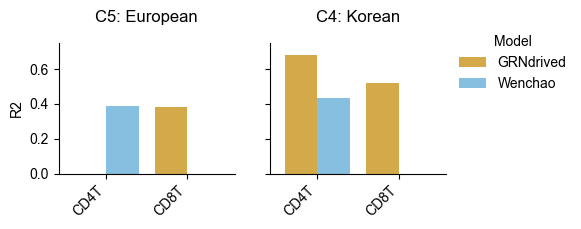

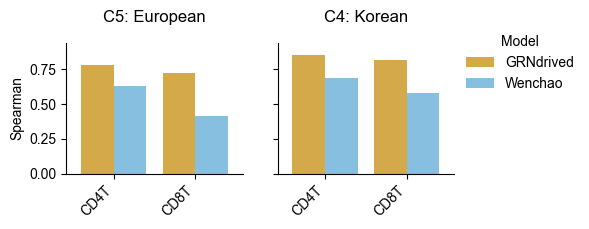

In [13]:
palette_models = {
    'Wenchao': colors_blind[1], 
    'GRNdrived': colors_blind[0]
}
# Clip R2 to [0, 1]
score_df['R2'] = score_df['R2'].clip(0, 1)

# Sort datasets for consistent layout
datasets = score_df['dataset'].unique()
n_datasets = len(datasets)

# Plot each metric in a separate figure
for metric in ['R2', 'Spearman']:
    fig, axes = plt.subplots(1, n_datasets, figsize=(2.5 * n_datasets, 1.7), sharey=True)

    if n_datasets == 1:
        axes = [axes]  # Ensure iterable if only one axis

    for ax, dataset in zip(axes, datasets):
        df_plot = score_df[score_df['dataset'] == dataset]

        sns.barplot(
            data=df_plot,
            x='cell_type',
            y=metric,
            hue='model',
            ax=ax,
            alpha=0.8,
            palette=palette_models,
        )   

        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.margins(x=0.1, y=0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.get_legend().remove()
        ax.set_title(f'{surrogate_names[dataset]}', pad=15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # fig.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/clock_comparison_{metric}.png', bbox_inches='tight', dpi=300, transparent=True)


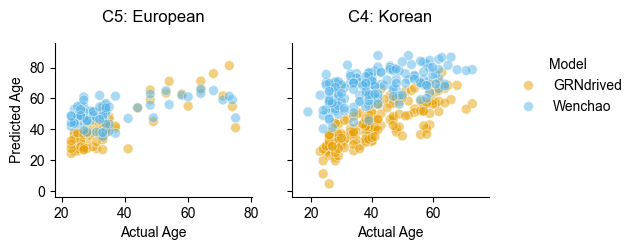

In [14]:
W_median_prediction['model'] = 'Wenchao'
test_predictions['model'] = 'GRNdrived'

obs = pd.concat([test_predictions, W_median_prediction], axis=0)
datasets = obs['dataset'].unique()

for cell_type in ['CD8T']:
    fig, axes = plt.subplots(1, len(datasets), figsize=(2.8*len(datasets), 2), sharey=True)
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, hue='model', palette=palette_models)
        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .5), frameon=False, title='Model')
    plt.savefig(f'{PLOTS_DIR}/clock_comparison_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
    
    # plt.suptitle(cell_type, fontsize=12, weight='bold')
    # plt.tight_layout()

# Disease: SLE

In [4]:
!cd ../ && python src/experiments/clock_analysis.py --dataset perez_sle --analysis-type disease --cell-types CD4T CD8T

Aging Clock Analysis - Disease
Dataset: perez_sle
Model version: all_data
Cell types: CD4T, CD8T
P-value threshold: 0.05
Output directory: /vol/projects/jnourisa//output//plots/

Loading predictions...
Retrieving consensus GRN for CD4T with min degree 2
Retrieving consensus GRN for CD8T with min degree 2
Loaded 526 predictions
Conditions: ['SLE' 'healthy']


Disease Analysis: perez_sle
Generating age acceleration plot...
  Saved: /vol/projects/jnourisa//output//plots/clock_perez_sle.png
Generating age-stratified plot for CD4T...

CD4T - Age residuals by age group:
Age Group    Mean Difference P-value    N_Control  N_Disease 
----------------------------------------------------------------------
[20, 50)        -3.10 yrs    1.820e-02  79         108       
[50, 80)        -3.61 yrs    1.673e-01  20         55        
  Saved: /vol/projects/jnourisa//output//plots/clock_perez_sle_bins_CD4T.png
Generating age-stratified plot for CD8T...

CD8T - Age residuals by age group:
Age Group    Mea

# Perturbation

In [ ]:
!cd ../ && python src/experiments/clock_analysis.py --dataset op --analysis-type perturbation --cell-types CD4T
!cd ../ && python src/experiments/clock_analysis.py --dataset CXCL9 --analysis-type perturbation --cell-types CD4T
!cd ../ && python src/experiments/clock_analysis.py --dataset parsebioscience --analysis-type perturbation --cell-types CD4T CD8T

Aging Clock Analysis - Perturbation
Dataset: op
Model version: all_data
Cell types: CD4T
P-value threshold: 0.05
Output directory: /vol/projects/jnourisa//output//plots/

Loading predictions...
Using layer X_norm
Retrieving consensus GRN for CD4T with min degree 2
Loaded 546 predictions
Conditions: ['TIE2 Kinase Inhibitor' 'MK-5108' 'Lapatinib' 'Belinostat' 'Dabrafenib'
 'Dimethyl Sulfoxide' 'Atorvastatin' 'Ganetespib (STA-9090)'
 'Clomipramine' 'Sunitinib' 'Tivozanib' 'Tamatinib' 'Ixabepilone'
 'Linagliptin'
 '5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-6-yl)pyrimidin-2-amine'
 'O-Demethylated Adapalene' 'Protriptyline' 'I-BET151' 'Foretinib'
 'GW843682X' 'Raloxifene' 'Topotecan' 'BAY 87-2243' 'Phenylbutazone'
 'K-02288' 'BMS-777607' 'Porcn Inhibitor III' 'TL_HRAS26' 'Vorinostat'
 'BMS-265246' 'Ruxolitinib' 'Pomalidomide' 'Dovitinib' 'AVL-292'
 'Navitoclax' 'Methotrexate' 'Palbociclib' 'Trametinib'
 'AMD-070 (hydrochloride)' 'Sgc-cbp30' 'FK 866' 'Chlorpheniramine'
 'Scriptaid' 'BAY 

# SoundLife - Aging Analysis

In [10]:
!cd ../ && python src/experiments/clock_analysis.py --dataset soundlife --config-label aging_cmv_neg --analysis-type aging --cell-types CD4T CD8T --data-type bulk

Aging Clock Analysis - Aging
Dataset: soundlife
Config label: aging_cmv_neg
Analysis type: aging
Cell types: CD4T, CD8T
P-value threshold: 0.05
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/

Loading predictions...
Loaded 1736 predictions
Conditions: ['healthy' 'CMV']

Applying data filters...
  Filtered by subject.cmv: ['Negative'] -> 952 samples remaining
After filtering: 952 predictions


Aging Analysis: soundlife
Configuration: aging_cmv_neg

Generating aging scatter plot for CD4T...
  Unpaired t-test (predicted age):
    Older (55-65y): 57.5 ± 5.5 (n=207)
    Young (25-35y): 32.6 ± 4.8 (n=269)
    Difference (old - young): -24.9, p=1.121e-182 ***
  Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/clock_soundlife_aging_cmv_neg_aging_CD4T.png

Generating aging scatter plot for CD8T...
  Unpaired t-test (predicted age):
    Older (55-65y): 57.1 ± 4.7 (n=207)
    Young (25-35y): 32.8 ± 3.6 (n=269)
    Difference (old - 